In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
import json, os
from sweep import sweep_load as sl
from sweep import raster
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib import colors
from cycler import cycler
import scipy.constants as const
from fractions import Fraction
%matplotlib inline

from utils import *

In [2]:
file_path = '../data/raw_sweeps'

In [3]:
rc_params = {
    'xtick.direction': 'in',
    'xtick.top': True,
    'ytick.direction': 'in',
    'ytick.right': True,
    'axes.edgecolor': 'k',
    'axes.labelcolor': 'k',
    'xtick.color': 'k',
    'ytick.color': 'k',
    'figure.facecolor': 'white',
    'font.size': 16,
    'axes.labelsize': 16,
    'legend.title_fontsize': 16,
    'axes.linewidth': 1.5,
    'xtick.major.size': 5,
    'xtick.major.width': 1.5,
    'xtick.minor.size': 2.5,
    'xtick.minor.width': 1.5,
    'ytick.major.size': 5,
    'ytick.major.width': 1.5,
    'ytick.minor.size': 2.5,
    'ytick.minor.width': 1.5,
    'lines.linewidth': 2.5,
    'figure.figsize': [3*1.618, 3]
}
plt.rcParams.update(rc_params)

In [4]:
h = 6.626E-34
e = 1.6002E-19
phi0 = h/e
dbg = 40.5
dtg = 26
ep = 3
Rq = h/e**2


In [5]:
with open('../rmg19.json', 'r') as f:
    rmg19 = json.load(f)


# !!! IMPORTANT NOTE !!!

in this document, I am going to keep some things in experimental units, for ease of deciding where to take data

In [6]:
rmg19['experimental']['dtg']

17.25

n_cal = 0.538


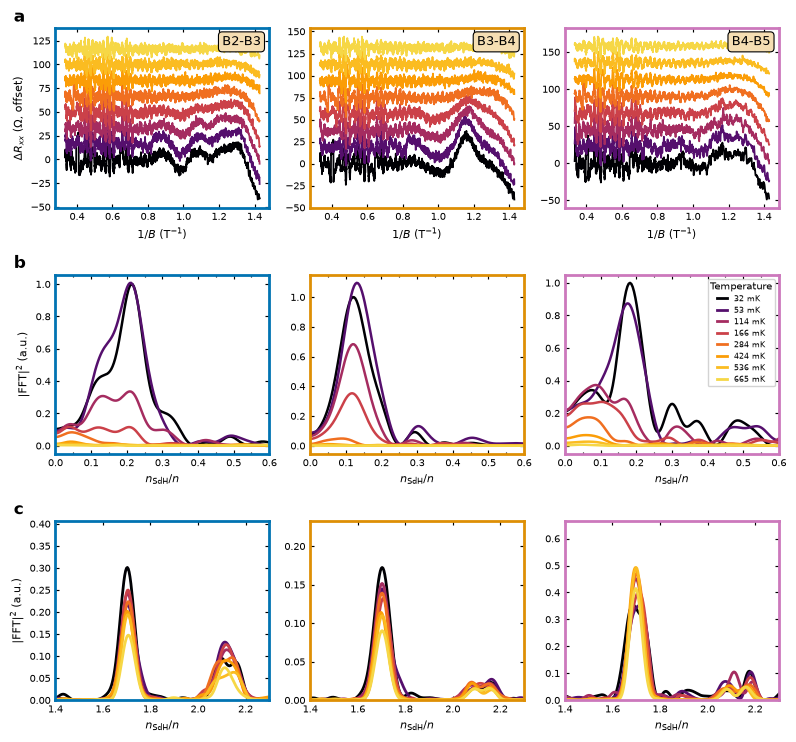

In [7]:
from matplotlib.lines import Line2D

# ---- Plot styling (matches linecut_fft_grid.py) ----
scale = 0.56
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.labelsize': 8, 'axes.titlesize': 8, 'font.size': 9,
    'legend.title_fontsize': 7, 'legend.fontsize': 7,
    'xtick.labelsize': 7, 'ytick.labelsize': 7,
    'xtick.direction': 'in', 'xtick.top': True,
    'ytick.direction': 'in', 'ytick.right': True,
    'xtick.major.size': 5*scale, 'xtick.major.width': 1.5*scale,
    'xtick.minor.size': 2.5*scale, 'xtick.minor.width': 1.5*scale,
    'ytick.major.size': 5*scale, 'ytick.major.width': 1.5*scale,
    'ytick.minor.size': 2.5*scale, 'ytick.minor.width': 1.5*scale,
    'axes.linewidth': 1.5*scale, 'lines.linewidth': 2.5*scale,
})

# Per-contact styling (column order matches contacts = (1, 2, 3))
contact_labels = ["B2-B3", "B3-B4", "B4-B5"]
contact_colors = ["#0173B2", "#DE8F05", "#CC78BC"]

# Mixing-chamber temperature per sweep, cached from the lab InfluxDB so this
# figure builds offline. Regenerate in the lab with, per file:
#     _, T = fetch_influxdb(file, 'AVS_bridge', 'P1_MixingCh_low', unit='kelvin')
#     temp = np.nanmean(T)                       # or data['T_probe'] if no 'T'
#     if np.nanmean(data['T']) > temp: temp = 0.053   # fridge-thermometer floor
# The `source` column records which branch produced each value.
import csv as _csv
with open('mixing_chamber_temperatures.csv') as _f:
    TEMPS = {int(r['file']): float(r['temperature_K']) for r in _csv.DictReader(_f)}

files = np.concatenate([np.arange(1804, 1811), [1822]])
contacts = [1, 2, 3]
ns, Ds = 0.59, 1
Vtg, Vbg = calculate_gate_voltages(ns, Ds, dtg=rmg19['experimental']['dtg'], dbg=rmg19['experimental']['dbg'])
n, D = calculate_n_D(Vtg, Vbg, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
print(f'n_cal = {n:.3f}')

blo, bhi = 0.7, 3
cutoff, order = 3.0, 2          # Butterworth high-pass in B (cycles/Tesla)
HIGH_F = (1.4, 2.3)             # zoom window for the high-frequency peak (~1.725)

# --- load once per file, process all contacts ---
per_c = {c: [] for c in contacts}
for file in files:
    data = sl.pload(file_path, file)
    xs = data['xs']
    I = data['sr830_4_X']
    temp = TEMPS[int(file)]
    flip = xs[0] > xs[-1]
    for c in contacts:
        zs = data[f'sr830_{c}_X'] / I
        xc, zc = (xs[::-1], zs[::-1]) if flip else (xs, zs)
        lo = np.abs(xc - blo).argmin(); hi = np.abs(xc - bhi).argmin()
        B_grid, Rxx_B = interp_rxx_B(xc[lo:hi], zc[lo:hi], nx=len(xc[lo:hi]))
        Rxx_dt_B, bg = detrend_butterworth(B_grid, Rxx_B, cutoff=cutoff, order=order, mode='highpass')
        Rxx_dt_B -= np.mean(Rxx_dt_B)
        invB, Rxx_dt = interp_rxx(B_grid, Rxx_dt_B, nx=len(B_grid))
        fft, freq_b = make_vec_fft(invB, Rxx_dt, n, padding=5, normalize=False)
        half = len(freq_b) // 2
        per_c[c].append(dict(temp=temp, invB=invB, Rxx_dt=Rxx_dt,
                             freq=freq_b[:half], fft=fft[:half]))

# --- sort each contact's series by temperature (cold -> hot) ---
for c in contacts:
    per_c[c].sort(key=lambda r: r['temp'])
temps = np.array([r['temp'] for r in per_c[contacts[0]]])

temp_cmap = colors.ListedColormap(plt.cm.inferno(np.linspace(0.0, 0.9, 256)))
temp_norm = colors.SymLogNorm(linthresh=0.05, vmin=temps.min(), vmax=temps.max())
def tcol(t): return temp_cmap(temp_norm(t))

# --- 3 rows (bg-Rxx, low-f tones, high-f peak) x 3 columns (contacts) ---
fig, axes = plt.subplots(3, 3, figsize=(8, 7.5))
for col, c in enumerate(contacts):
    recs = per_c[c]
    fft_norm = np.amax(recs[0]['fft'])
    step = 2.5 * np.median([np.std(r['Rxx_dt']) for r in recs])
    ax_rxx, ax_low, ax_high = axes[0, col], axes[1, col], axes[2, col]
    for i, r in enumerate(recs):
        cc = tcol(r['temp'])
        ax_rxx.plot(r['invB'], r['Rxx_dt'] + i*step, color=cc, lw=1.3)
        ax_low.plot(r['freq'], r['fft']/fft_norm, color=cc, lw=1.8)
        ax_high.plot(r['freq'], r['fft']/fft_norm, color=cc, lw=2.0)
    ax_low.set_xlim(0, 0.6)
    ax_low.xaxis.set_minor_locator(MultipleLocator(0.05))
    ax_high.set_xlim(*HIGH_F)
    hmax = max(float((r['fft']/fft_norm)[(r['freq'] >= HIGH_F[0]) & (r['freq'] <= HIGH_F[1])].max()) for r in recs)
    ax_high.set_ylim(0, 1.35*hmax)
    ax_rxx.set_xlabel(r'$1/B$ (T$^{-1}$)')
    ax_low.set_xlabel(r'$n_{\mathrm{SdH}}/n$')
    ax_high.set_xlabel(r'$n_{\mathrm{SdH}}/n$')

    # colored spines on every row of this contact's column
    for ax in (ax_rxx, ax_low, ax_high):
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2)
            spine.set_edgecolor(contact_colors[col])
    # boxed contact label, top row only
    ax_rxx.text(0.96, 0.96, contact_labels[col], transform=ax_rxx.transAxes,
                ha='right', va='top', fontsize=9, color='k',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat',
                          edgecolor='k', linewidth=0.8, alpha=1))

axes[0, 0].set_ylabel(r'$\Delta R_{xx}$ ($\Omega$, offset)')
axes[1, 0].set_ylabel(r'$|\mathrm{FFT}|^2$ (a.u.)')
axes[2, 0].set_ylabel(r'$|\mathrm{FFT}|^2$ (a.u.)')

# bold lower-case row labels a/b/c (top-left of the leftmost column)
for row, letter in zip(range(3), ['a', 'b', 'c']):
    axes[row, 0].annotate(letter, xy=(0, 1), xycoords='axes fraction',
                          xytext=(-30, 2), textcoords='offset points',
                          fontweight='bold', fontsize=12, va='bottom', ha='left')

# single temperature legend (sorted)
handles = [Line2D([0], [0], color=tcol(t), lw=2, label=f'{t*1e3:.0f} mK') for t in temps]
axes[1, 2].legend(handles=handles, loc='upper right', ncol=1, fontsize=6,
                  title='Temperature', framealpha=0.85,
                  handlelength=1.2, labelspacing=0.3, borderpad=0.3)

fig.tight_layout()
fig.savefig('csc_qo-T-dep_3x3.pdf', bbox_inches='tight')
plt.show()